# Donut 도면(Drawing) 파인튜닝 노트북

`donut_training.ipynb`(영수증/CORD용)를 **기계 도면 표제란 정보 추출** 태스크(도면 요소 추출)에 맞게 변형한 노트북입니다.

- 입력: `data/drawings/images/*.png` (도면 이미지)
- 정답: `data/drawings/labels/*.json` (도면번호/재질/공차/볼트홀 등 스키마)
- 태스크 토큰: **`<s_drawing>`** 
- 베이스 모델: `naver-clova-ix/donut-base` (영수증 파인튜닝본이 아님)
- 학습 출력: `checkpoints_drawings/` (영수증 체크포인트와 분리)

> ⚠️ **데이터가 적습니다(≈50장).** Donut 기준으로는 매우 작은 규모라 데모/PoC 수준입니다.
> 실사용 품질을 원하면 도면 수를 늘리고 라벨의 빈 값을 최대한 채우세요.

### 실행 순서
1. 환경 확인 → 2. 설정(CFG) → 3. 라벨 점검 → 4. 데이터 분리 →
5. 모델 로드 → 6. 데이터셋 구성 → 7. 학습 → 8. 평가 → 9. 추론


## Donut 파인튜닝 과정 상세 설명

---

### 1. 전체 흐름 한눈에 보기

```
    [이미지 입력]                     [정답 JSON]
           │                               │
           ▼                               ▼
  ┌─────────────────┐           ┌──────────────────┐
  │  DonutProcessor │           │   json2token()   │
  │  resize / norm  │           │   dict → token   │
  └────────┬────────┘           └────────┬─────────┘
           │ pixel_values                │ target_seq
           └──────────────┬──────────────┘
                          ▼
       ╔══════════════════════════════════════╗
       ║      VisionEncoderDecoderModel       ║
       ║                                      ║
       ║  ┌─────────────────┐  ┌───────────┐  ║
       ║  │     Swin-T      │─▶│   BART    │  ║
       ║  │    (Encoder)    │  │ (Decoder) │  ║
       ║  └─────────────────┘  └─────┬─────┘  ║
       ╚═════════════════════════════╧════════╝
                                     │ logits
                                     ▼
                           CrossEntropyLoss
                                     │
                                     ▼
                          역전파 / 가중치 업데이트
```

---

### 2. 각 구성 요소 역할

| 구성 요소 | 역할 | 출력 형태 |
|:---|:---|:---|
| **DonutProcessor** | 이미지 리사이즈 → `[1280×960]`, 픽셀 정규화 `[-1, 1]` | `(C, H, W)` 텐서 |
| **Swin Transformer** | 이미지를 패치 단위로 분석, 시각적 특징 추출 | `(seq_len, hidden_dim)` |
| **BART Decoder** | 인코더 feature + 이전 토큰 → 다음 토큰 예측 | 토큰 시퀀스 |
| **json2token()** | Python dict → `<s_key>value</s_key>` XML 형식 변환 | 문자열 |
| **token2json()** | 생성된 토큰 시퀀스 → Python dict 역변환 | dict |

---

### 3. Teacher Forcing — 학습 방식

| 구분 | 추론 시 (자유 생성) | 학습 시 (Teacher Forcing) |
|:---:|:---|:---|
| **다음 입력** | 이전 **예측** 토큰 사용 | 이전 **정답** 토큰 사용 |
| **특징** | 오류가 누적될 수 있음 | 안정적이고 빠른 학습 |
| **예시** | `<s_total>` → `1200` → ... (틀려도 진행) | `<s_total>` → `12500` → ... (항상 정답 제공) |

---

### 4. Loss 계산 — 모델이 무엇을 배우는가

```python
# 정답 레이블 (labels)
[<s_total>, 1, 2, 5, 0, 0, </s_total>, PAD, PAD ...]
    →  token ids: [102, 49, 50, 53, 48, 48, 103, -100, -100 ...]
                                                  ^^^^^^^^^^^^
                                            패딩: -100으로 마스킹 → loss 제외

# CrossEntropyLoss
loss = -log(P(정답 토큰))     # 정답 토큰의 예측 확률이 높을수록 loss 감소
```

> **핵심:** loss가 낮아진다 = 모델이 정답 토큰을 더 높은 확률로 예측하게 됨

---

### 5. 파인튜닝 vs 처음부터 학습 (From Scratch)

| 항목 | ✅ 파인튜닝 | ❌ From Scratch |
|:---|:---:|:---:|
| 시작 가중치 | 사전학습 완료 (문서 이해 능력 보유) | 랜덤 초기화 |
| 필요 데이터 | 수백 ~ 수천 장 | 수십만 장 이상 |
| 학습 시간 | 수 시간 ~ 수 일 | 수 주 ~ 수 개월 |
| GPU 비용 | 낮음 | 매우 높음 |
| 권장 상황 | **대부분의 실무** | 완전히 새로운 도메인 |

> **결론:** 실무에서는 거의 항상 파인튜닝을 사용합니다.

---

### 6. 학습 중 모니터링 지표

| 지표 | 의미 | 정상 패턴 | 이상 신호 |
|:---|:---|:---:|:---:|
| `train_loss` | 학습 데이터 오차 | 지속 감소 ↘ | 감소 없이 진동 |
| `eval_loss` | 검증 데이터 오차 | 감소 후 수렴 | **증가 시작** → 과적합 |
| `grad_norm` | 그래디언트 크기 | 안정적 유지 | 급격히 증가 → 폭발 |

```
loss
  │
8 │ ╲
6 │  ╲
4 │   ╲──╮
2 │      ╰──────────── ← 수렴 (이상적)
  │                  ╰── eval_loss 증가 시 → 과적합
  └──────────────────────────────── step
     초기 급감        수렴 구간
```

**과적합 방지 설정:**
- `save_total_limit=3` — 최신 체크포인트 3개만 유지
- `load_best_model_at_end=True` — 학습 종료 후 eval_loss 최저 모델 자동 복원

In [1]:
# ── widget 렌더러 오류 방지 (VS Code Jupyter) ─────────────────────
# tqdm.auto 및 HuggingFace 내부 progress bar가 ipywidget을
# 사용하지 않도록 강제합니다 — 텍스트 모드로 출력됩니다.
import os
os.environ['TQDM_NOTEBOOK'] = 'false'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'  # tokenizer 경고 억제

# ── Step 0: 환경 확인 ──────────────────────────────────────────────
# 학습에 필요한 라이브러리 버전과 GPU 상태를 먼저 점검합니다.
# CUDA가 False이면 GPU를 인식하지 못한 것 — 드라이버/환경을 확인하세요.
import torch
import transformers
import platform

print(f"Python     : {platform.python_version()}")
print(f"PyTorch    : {torch.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"CUDA 사용   : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU        : {torch.cuda.get_device_name(0)}")
    print(f"VRAM       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Python     : 3.10.19
PyTorch    : 2.11.0+cu130
Transformers: 4.57.6
CUDA 사용   : True
GPU        : NVIDIA GB10
VRAM       : 130.7 GB


In [2]:
# ── 필수 패키지 설치 확인 ─────────────────────────────────────────
# 이미 설치된 경우 무시됩니다 — 매번 실행해도 안전합니다.
# datasets  : HuggingFace 데이터셋 다운로드 라이브러리
# sentencepiece : Donut 토크나이저가 내부적으로 사용하는 형태소 분석기
import importlib, subprocess, sys

required = {"datasets": "datasets", "sentencepiece": "sentencepiece"}
missing  = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]

if missing:
    print(f"설치 중: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing, "-q"])
    print("설치 완료 — 커널을 재시작하지 않아도 됩니다.")
else:
    print("모든 패키지 설치 확인 ✓")


모든 패키지 설치 확인 ✓


In [3]:
# ── 공통 Import ───────────────────────────────────────────────────
import json       # JSON 파일 읽기/쓰기
import os         # 파일 경로, 디렉터리 생성
import random     # 데이터셋 셔플 및 시드 고정
import re         # 정규표현식 (토큰 파싱에 사용)
import shutil
import tempfile
from pathlib import Path  # 운영체제 독립적인 파일 경로 처리

import numpy as np         # 수치 연산 및 시드 고정
from PIL import Image      # 이미지 파일 열기/변환
# tqdm.auto는 VS Code Jupyter에서 ipywidget 오류를 유발하므로 tqdm 직접 사용
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader  # 커스텀 데이터셋 클래스

from transformers import (
    DonutProcessor,              # 이미지 전처리 + 텍스트 토크나이저 통합 유틸리티
    VisionEncoderDecoderModel,   # 인코더(Swin-T) + 디코더(BART) 통합 모델
    Seq2SeqTrainer,              # Seq2Seq 학습 자동화 (forward/backward/저장)
    Seq2SeqTrainingArguments,    # 학습 하이퍼파라미터 설정
)

# ── matplotlib 전역 스타일 설정 ────────────────────────────────────
# 흰 배경에서도 텍스트/축/선이 선명하게 보이도록 전역 적용
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({
    "figure.facecolor": "white",   # 그림 배경 흰색
    "axes.facecolor":   "white",   # 축 영역 배경 흰색
    "savefig.facecolor":"white",   # 저장 시에도 흰 배경
    "text.color":       "black",   # 모든 텍스트 검정
    "axes.labelcolor":  "black",   # 축 레이블 검정
    "xtick.color":      "black",   # x축 눈금 검정
    "ytick.color":      "black",   # y축 눈금 검정
    "axes.edgecolor":   "black",   # 축 테두리 검정
})

# ── 한글 폰트 설정 (plot 한글 깨짐 / Glyph 경고 방지) ──────────────
# 시스템의 Noto Sans CJK(KR 포함)를 등록해 matplotlib 기본 폰트로 사용
from matplotlib import font_manager as _fm
_ko_font = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
try:
    _fm.fontManager.addfont(_ko_font)
    matplotlib.rcParams["font.family"] = _fm.FontProperties(fname=_ko_font).get_name()
except Exception as _e:
    print("한글 폰트 등록 실패(영문만 표시됨):", _e)
matplotlib.rcParams["axes.unicode_minus"] = False   # 마이너스 기호 깨짐 방지

print("Import 완료 ✓  (한글 폰트:", matplotlib.rcParams["font.family"], ")")


Import 완료 ✓  (한글 폰트: ['Noto Sans CJK JP'] )


## Step 1 – 설정 (Configuration)

모든 하이퍼파라미터를 딕셔너리로 관리합니다.  
`dataset_name`을 `None`으로 바꾸고 `local_train_dir` / `local_val_dir`을 지정하면 커스텀 데이터셋을 사용할 수 있습니다.

In [4]:
# ── Step 1: 설정 (도면 파인튜닝용) ───────────────
# 도면(drawing) 데이터 전용 설정입니다.
# 영수증(CORD) 노트북과 달리 처음부터 로컬 모드 + <s_drawing> 태스크로 맞춰져 있습니다.
CFG = {
    "model": {
        # 영수증 파인튜닝본이 아닌 '순수 베이스 모델'에서 출발합니다.
        "pretrained_model_name": "naver-clova-ix/donut-base",
        # 도면 JSON은 notes 등으로 길어질 수 있어 디코더 최대 길이를 키웁니다.
        # (donut-base 디코더 위치 임베딩 한계 = 768)
        "max_length": 768,
        # 도면은 글자가 작고 촘촘하므로 해상도가 중요합니다. VRAM 여유가 있으면 키우세요.
        "image_size": [1280, 960],
    },
    "data": {
        "dataset_name": None,                 # 로컬 모드
        "task_prompt": "<s_drawing>",       # 태스크 토큰 (표제란 필드명은 title_block 이라 충돌 없음)         # 도면 태스크 토큰
        "local_train_dir": "data/processed_drawings/train",
        "local_val_dir":   "data/processed_drawings/val",
    },
    "training": {
        "output_dir": "checkpoints_drawings", # 영수증 체크포인트와 분리
        "num_epochs": 100,        # 데이터가 적으므로(≈50장) 에폭을 크게
        "batch_size": 2,          # VRAM 부족 시 1로 낮추고 grad_accum을 올리세요
        "gradient_accumulation_steps": 2,     # 실효 배치 = 2 × 2 = 4 (소규모 데이터: 업데이트 횟수 확보가 수렴에 중요)
        "learning_rate": 3e-5,
        "warmup_steps": 50,       # 총 스텝 수가 적으므로 웜업도 짧게
        "weight_decay": 0.01,
        "bf16": True,             # bf16 권장 (fp16은 Donut에서 불안정)
        "fp16": False,
        "save_steps": 50,         # 데이터가 적어 스텝 수가 작음 → 자주 저장/평가
        "eval_steps": 50,
        "logging_steps": 10,
        "dataloader_num_workers": 4,
        "seed": 42,
    },
    "wandb": {
        "enabled": False,
        "project": "donut-drawings",
        "run_name": None,
    },
}

print("Config (도면) loaded ✓")
print(f"  모델     : {CFG['model']['pretrained_model_name']}")
print(f"  태스크   : {CFG['data']['task_prompt']}")
print(f"  학습 출력: {CFG['training']['output_dir']}")


Config (도면) loaded ✓
  모델     : naver-clova-ix/donut-base
  태스크   : <s_drawing>
  학습 출력: checkpoints_drawings


In [5]:
# ── 재현성을 위한 시드 고정 ────────────────────────────────────────
# 동일한 시드를 설정하면 같은 코드를 다시 실행해도 동일한 결과가 나옵니다.
# Python / NumPy / PyTorch / CUDA 각각의 난수 생성기를 모두 고정해야 합니다.
def set_seed(seed: int):
    random.seed(seed)        # Python 기본 random 모듈
    np.random.seed(seed)     # NumPy 난수
    torch.manual_seed(seed)  # CPU 연산 난수
    torch.cuda.manual_seed_all(seed)  # GPU 연산 난수 (멀티GPU 포함)

set_seed(CFG["training"]["seed"])
print(f"Seed = {CFG['training']['seed']} 고정 완료")


Seed = 42 고정 완료


## 도면 데이터셋 준비 (`data/drawings` → `data/processed_drawings`)

`data/drawings/images/*.png` 와 같은 이름의 `data/drawings/labels/*.json` 쌍을
train/val로 분리하여 `DonutDataset`이 읽는 구조로 복사합니다.

> 새 이미지를 추가했다면 먼저 `python data/drawings/annotate_helper.py`로
> 빈 JSON 템플릿을 만든 뒤 값을 채우세요.


## 라벨 구조(스키마)는 어떤 원리로 만들어지나

라벨 JSON의 구조(`drawing`, `dimensions`, `bolt_holes` …)는 **모델이 자동으로 만든 것이 아니라,
사람이 미리 설계한 "스키마(schema)"** 입니다. Donut은 이 구조를 그대로 외워서 출력하도록 학습됩니다.

### 1. 어디서 정의되나

스키마는 모델이 만든 게 아니라 **사람이 설계**한 것으로, `annotate_helper.py`의 `TEMPLATE` 딕셔너리에 정의됩니다.
(템플릿 생성·라벨링 절차는 다음 셀 **"라벨은 어떻게 만들어지나"** 참고)

```python
TEMPLATE = {
    "title_block": {"title": "", "Rev": "", "Drawing_no": "", "LIC_Material": "", "Material": "", "Material_std": ""},
    "dimensions":  {"outer_diameter": "", "bore_diameter": "", "thickness": "", "pilot_od": "", ...},
    "bolt_holes":  {"outer": {...}, "inner": {...}},
    "surface_finish": {...}, "gdt": {...}, "threads": [], "date": "",
}
```

### 2. 설계 원리 4가지

| 원리 | 의미 | 이 스키마에서의 예 |
|------|------|---------------------|
| **① 도메인 분석** | "이 문서에서 무엇을 추출할지" 먼저 정함 | 도면 → 도면번호·치수·재질·공차·볼트홀 |
| **② 의미별 그룹화(중첩)** | 관련 항목을 한 객체로 묶음 | 번호/제목/재질 → `title_block`, 외경/내경/두께 → `dimensions` |
| **③ 일관성** | 모든 라벨이 동일한 키를 가져야 함 | 도면에 없으면 값은 `N/A`로 두되 **키는 유지** |
| **④ 반복은 리스트** | 개수가 가변인 항목은 배열로 | `threads: ["M16", "M20"]` |

### 3. 중첩(nesting)을 하는 이유

`bolt_holes`처럼 한 단계 더 묶는 것은 **현실의 구조를 반영**하기 위해서입니다.

```
bolt_holes              ← "볼트홀"이라는 큰 묶음
├── outer (바깥쪽)      ← 같은 속성(count/diameter/pcd)을 가진 그룹
└── inner (안쪽)        ← 같은 속성을 가진 또 다른 그룹
```

평평하게 `outer_count`, `inner_count`로 풀 수도 있지만, 중첩하면 "바깥/안쪽 볼트홀이 각각
개수·지름·PCD를 가진다"는 관계가 구조에 그대로 드러납니다.

### 4. 학습과의 연결 — `json2token`

중요한 점: **Donut은 이 구조를 "이해"하는 게 아니라, 이미지를 보면 이 토큰 순서를 그대로 생성하도록 학습**합니다.
`json2token`이 중첩 구조를 XML 토큰으로 1:1 변환합니다(키는 역순 정렬).

```
JSON                                          토큰 시퀀스
"title_block": {"title": "SP.FLANGE", ...}
   → <s_title_block><s_title>SP.FLANGE</s_title> ... </s_title_block>

"bolt_holes": {"outer": {"count": "4", ...}}
   → <s_bolt_holes><s_outer><s_count>4</s_count> ... </s_outer> ... </s_bolt_holes>

"threads": ["M16", "M20"]
   → <s_threads>M16<sep/>M20</s_threads>
```

즉 **중첩 dict → 중첩 태그**, **리스트 → `<sep/>`로 구분된 항목**으로 변환됩니다.
스키마를 어떻게 설계하든 그 구조 그대로 토큰 트리가 만들어지고 모델은 그것을 학습합니다.

> **스키마를 바꾸려면?** `annotate_helper.py`의 `TEMPLATE`를 수정하고 라벨을 다시 생성하면 됩니다.
> 단, 바꾼 뒤에는 **모든 라벨의 키 구조를 다시 일관되게** 맞춰야 합니다.


## 라벨은 어떻게 만들어지나 — `annotate_helper.py` 와 라벨링 과정

파인튜닝의 출발점은 **이미지 + 정답(라벨)** 쌍입니다. Donut은 이미지를 보고 이 정답 JSON을
그대로 생성하도록 학습하므로, **라벨 품질이 곧 모델 품질**입니다. 그 라벨을 만드는 보조 도구가
`data/drawings/annotate_helper.py` 입니다.

### 1. 이 스크립트의 역할 (딱 한 가지)

`images/` 의 각 이미지마다, **빈칸으로 된 JSON 템플릿**을 `labels/` 에 만들어 줍니다.
- 값을 채워주지는 **않습니다**. "양식"만 깔아주는 도구입니다.
- 이미 라벨이 있는 이미지는 **건너뜁니다** (덮어쓰지 않음 → 작업한 내용 보존).

```
data/drawings/
├── images/  A14-636074-7.png   ← 사람이 넣은 도면 이미지
└── labels/  A14-636074-7.json  ← 스크립트가 만든 빈 템플릿 (값은 사람이 채움)
```

### 2. 핵심 = `TEMPLATE` (스키마 정의)

스크립트 안의 `TEMPLATE` 딕셔너리가 **모든 라벨의 구조(스키마)** 를 결정합니다.
이걸 복사해 각 `*.json` 이 생성되므로, **모든 라벨이 같은 키 구조**를 갖게 됩니다.
스키마를 바꾸려면 이 `TEMPLATE` 을 수정합니다. (예: `title_block`, `dimensions` 필드 구성)

### 3. 전체 라벨링 워크플로우

```
[1] images/ 에 도면 PNG 넣기
          │
          ▼
[2] python data/drawings/annotate_helper.py   ← 빈 JSON 템플릿 자동 생성
          │
          ▼
[3] labels/*.json 을 열어 도면을 보고 값 채우기  ← ★사람의 핵심 작업★
    · 표제란(도면번호/부품명/재질…) 전사
    · 치수·볼트홀·공차 입력
    · 해당 도면에 없는 항목은 "N/A"
          │
          ▼
[4] (이 노트북) 데이터 분리 → 학습 → 추론
```

> **핵심 구분**
> - `annotate_helper.py` = **양식(빈 템플릿) 생성** — 자동, 한 번 실행
> - **값 채우기 = 사람의 수작업** — 도면을 직접 읽어 전사 (모델 정확도를 좌우)
> - **학습은 `TEMPLATE`이 아니라 채워진 `labels/*.json` 에서** 키·값을 읽습니다.
>   즉 `TEMPLATE` 만 바꾸고 라벨을 안 바꾸면 학습 결과는 그대로입니다.

### 4. 라벨 품질 원칙

| 원칙 | 이유 |
|------|------|
| 빈칸 대신 `"N/A"` | 모델이 "해당 없음"을 일관된 토큰으로 학습 (빈 문자열보다 안정적) |
| 모든 라벨 키 구조 통일 | 스키마가 들쭉날쭉하면 학습이 불안정 |
| 틀린 값 < 빈칸(N/A) | **잘못 채운 라벨은 N/A보다 나쁨** — 모델이 틀린 값을 정답으로 학습 |
| 값은 도면과 대조 검토 | 라벨 = 정답지. 오독이 그대로 모델 오류가 됨 |

> 다음 셀(**라벨 품질 점검**, **라벨 ↔ 이미지 대조**)로 위 원칙이 지켜졌는지 확인할 수 있습니다.


In [6]:
# ── 라벨 품질 점검 (선택) ──────────────────
# 학습 전에 라벨 JSON이 모두 유효한지, 빈 값이 얼마나 많은지 확인합니다.
# 빈 값("")이 많으면 모델이 '빈 칸 출력'을 학습하므로 가능한 한 채우세요.
from pathlib import Path
import json

DRAW_DIR = Path("data/drawings")
img_dir, lbl_dir = DRAW_DIR / "images", DRAW_DIR / "labels"

def count_leaves(obj):
    total = empty = 0
    if isinstance(obj, dict):
        for v in obj.values():
            t, e = count_leaves(v); total += t; empty += e
    elif isinstance(obj, list):
        for v in obj:
            t, e = count_leaves(v); total += t; empty += e
    else:
        total = 1
        if obj in ("", None):
            empty = 1
    return total, empty

imgs = sorted(p for p in img_dir.glob("*") if p.suffix.lower() in {".png", ".jpg", ".jpeg"})
n_pairs = n_total = n_empty = 0
bad = []
for img in imgs:
    lbl = lbl_dir / (img.stem + ".json")
    if not lbl.exists():
        bad.append(f"라벨 없음: {img.name}"); continue
    try:
        obj = json.loads(lbl.read_text(encoding="utf-8"))
    except Exception as e:
        bad.append(f"JSON 파싱 오류: {lbl.name} ({e})"); continue
    n_pairs += 1
    t, e = count_leaves(obj); n_total += t; n_empty += e

print(f"이미지 {len(imgs)}개 / 유효 쌍 {n_pairs}개")
pct = (n_empty / n_total * 100) if n_total else 0
print(f"전체 leaf {n_total}개 중 빈 값 {n_empty}개 ({pct:.1f}%)")
if bad:
    print("\n⚠️ 문제 항목:")
    for b in bad[:20]:
        print("  -", b)
else:
    print("문제 없음 ✓")


이미지 50개 / 유효 쌍 50개
전체 leaf 1172개 중 빈 값 0개 (0.0%)
문제 없음 ✓


## ⚠️ 라벨은 사람이 이미지와 대조해 검토해야 합니다

라벨(JSON)은 **모델이 배우는 "정답지"** 입니다. 라벨이 틀리면 모델은 틀린 값을 정답으로 학습하므로,
학습 전에 **도면 이미지와 라벨 값이 일치하는지 사람이 확인**하는 단계가 필요합니다.

### 검토가 필요한 두 가지 불확실성

| 구분 | 상태 | 사람이 할 일 |
|------|------|--------------|
| **원래 채워져 있던 값** (예: `outer_diameter: "120"`, `title_block.Material: "SUS316L"`) | 전사 과정의 오타·오독 가능 | 이미지와 대조해 맞는지 확인 |
| **`N/A`로 정규화한 값** | 빈칸을 일괄로 `N/A` 처리함 | 도면에 **실제 값이 있는데** `N/A`로 덮은 건 아닌지 확인 |

특히 두 번째가 핵심입니다. 예) `A1463607470` 도면:
- `surface_finish.general: "12.5"` → 값이 있음
- `surface_finish.machined: "N/A"` → 도면에 가공면 조도 기호가 정말 없는지 확인 필요
- `gdt.*: "N/A"` → 도면에 기하공차 기호(⊥, //, ◎ 등)가 정말 없는지 확인 필요

### 검토 우선순위 (위험도 순)

1. **`N/A`로 채운 필드** — 도면에 값이 있는데 놓쳤을 수 있는 곳 (`surface_finish`, `gdt`가 대표적)
2. **치수·재질 등 측정값** — 오독 시 모델이 엉뚱한 숫자를 학습
3. **도면번호·제목** — 표제란에 크게 적혀 있어 비교적 안전

> 💡 아래 "라벨 ↔ 이미지 대조" 셀을 실행하면 도면과 해당 JSON을 나란히 띄워 빠르게 눈으로 검토할 수 있습니다.


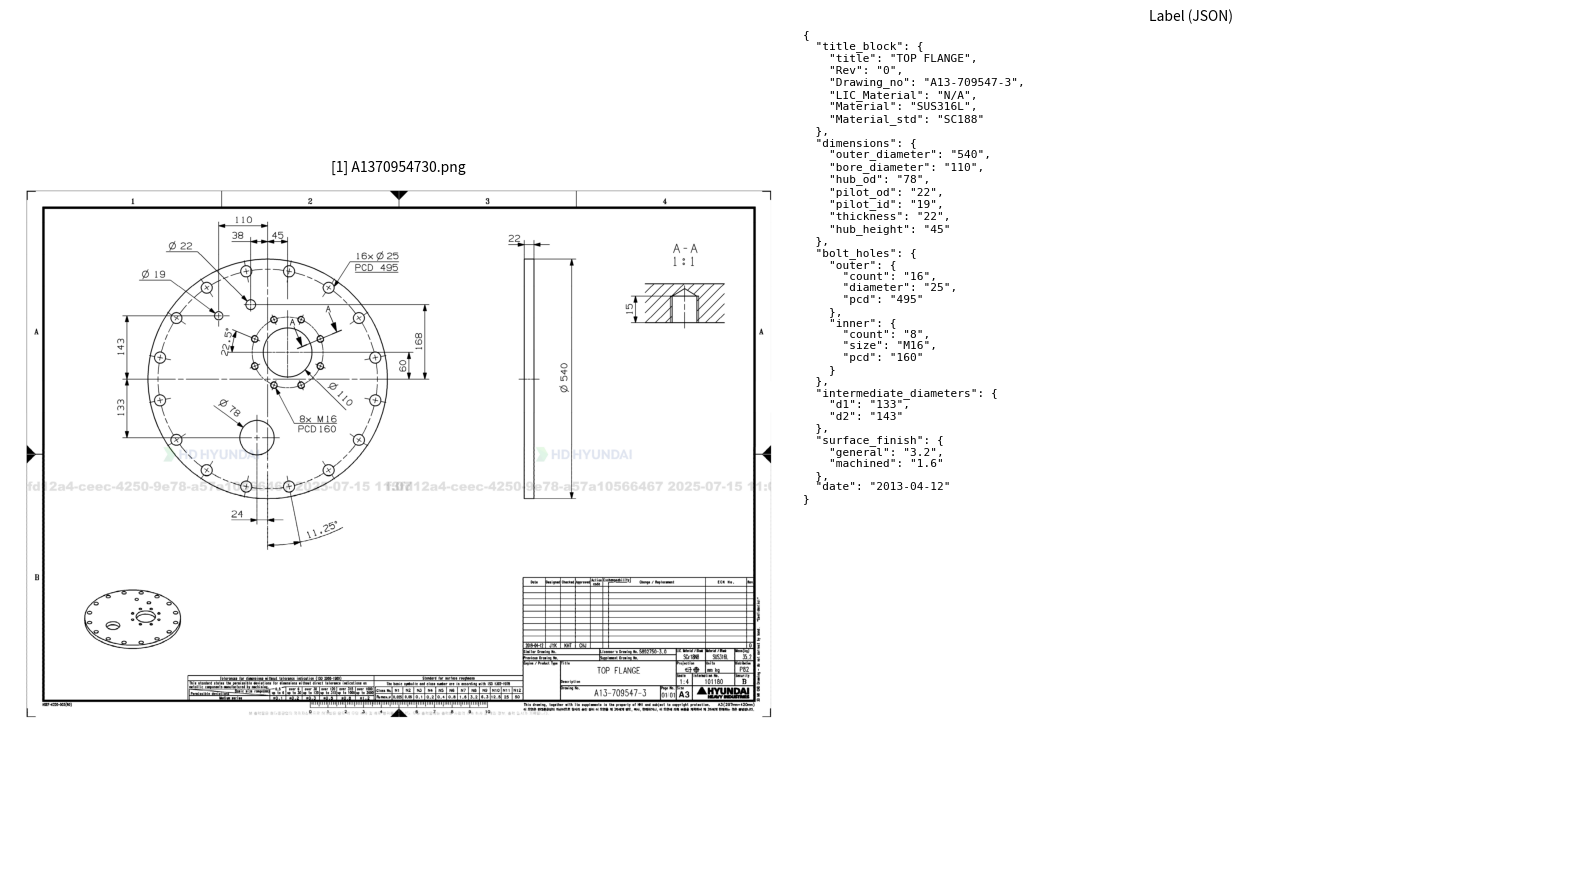

N/A 필드 1개 — 도면에 실제 값이 있는지 우선 확인:
  - /title_block/LIC_Material


In [7]:
# ── 라벨 ↔ 이미지 대조 (검토용) ──────────────
# 도면 이미지와 해당 라벨 JSON을 나란히 띄워 사람이 눈으로 검토합니다.
# IDX만 바꿔가며 한 장씩 확인하세요 (0 ~ 49).
import json
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

DRAW_DIR = Path("data/drawings")
imgs = sorted(p for p in (DRAW_DIR / "images").glob("*")
              if p.suffix.lower() in {".png", ".jpg", ".jpeg"})

IDX = 1   # ← 검토할 이미지 번호 (0부터)

img_path = imgs[IDX]
lbl_path = DRAW_DIR / "labels" / (img_path.stem + ".json")
label = json.loads(lbl_path.read_text(encoding="utf-8"))

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
axes[0].imshow(Image.open(img_path).convert("RGB"))
axes[0].axis("off")
axes[0].set_title(f"[{IDX}] {img_path.name}", fontsize=10)

axes[1].axis("off")
axes[1].set_title("Label (JSON)", fontsize=10)
axes[1].text(0.0, 1.0, json.dumps(label, indent=2, ensure_ascii=False),
             transform=axes[1].transAxes, fontsize=8,
             va="top", ha="left", fontfamily="monospace")
plt.tight_layout()
plt.show()

# N/A로 채워진 필드 = 도면에 실제 값이 있는지 우선 확인할 후보
def na_paths(obj, prefix=""):
    out = []
    if isinstance(obj, dict):
        for k, v in obj.items():
            out += na_paths(v, f"{prefix}/{k}")
    elif isinstance(obj, list):
        for i, v in enumerate(obj):
            out += na_paths(v, f"{prefix}[{i}]")
    elif obj == "N/A":
        out.append(prefix)
    return out

nas = na_paths(label)
print(f"N/A 필드 {len(nas)}개 — 도면에 실제 값이 있는지 우선 확인:")
for p in nas:
    print("  -", p)


In [8]:
# ── 도면 데이터 train/val 분리 ─────────────────
import shutil, json, random
from pathlib import Path

SRC_DIR    = Path("data/drawings")            # 원본 이미지+JSON
OUT_DIR    = Path("data/processed_drawings")  # 정리 결과
VAL_RATIO  = 0.1
SEED       = CFG["training"]["seed"]
DROP_EMPTY = False   # True면 빈 값("")인 필드를 제거하고 저장 (이미지마다 스키마가 달라질 수 있음)

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".tiff", ".bmp"}

def drop_empty(obj):
    if isinstance(obj, dict):
        out = {}
        for k, v in obj.items():
            v2 = drop_empty(v)
            if v2 not in ("", None, {}, []):
                out[k] = v2
        return out
    if isinstance(obj, list):
        return [drop_empty(v) for v in obj if drop_empty(v) not in ("", None, {}, [])]
    return obj

# 이미지-라벨 쌍 수집 (images/ + labels/ 구조)
pairs = []
for img in sorted(SRC_DIR.glob("images/*")):
    if img.suffix.lower() not in IMAGE_EXTS:
        continue
    label = SRC_DIR / "labels" / (img.stem + ".json")
    if label.exists():
        pairs.append((img, label))

if not pairs:
    print(f"이미지+JSON 쌍을 찾을 수 없습니다: {SRC_DIR}")
else:
    random.seed(SEED)
    random.shuffle(pairs)
    n_val       = max(1, int(len(pairs) * VAL_RATIO))
    val_pairs   = pairs[:n_val]
    train_pairs = pairs[n_val:]

    # 재실행 시 중복 방지를 위해 기존 출력 폴더 초기화
    if OUT_DIR.exists():
        shutil.rmtree(OUT_DIR)

    for split_name, split_pairs in [("train", train_pairs), ("val", val_pairs)]:
        img_out = OUT_DIR / split_name / "images"
        lbl_out = OUT_DIR / split_name / "labels"
        img_out.mkdir(parents=True, exist_ok=True)
        lbl_out.mkdir(parents=True, exist_ok=True)
        for img_path, lbl_path in split_pairs:
            shutil.copy2(img_path, img_out / img_path.name)
            if DROP_EMPTY:
                obj = json.loads(lbl_path.read_text(encoding="utf-8"))
                (lbl_out / lbl_path.name).write_text(
                    json.dumps(drop_empty(obj), ensure_ascii=False, indent=2),
                    encoding="utf-8")
            else:
                shutil.copy2(lbl_path, lbl_out / lbl_path.name)

    # CFG 로컬 경로 동기화 (CFG에 이미 설정되어 있지만 재확인)
    CFG["data"]["dataset_name"]    = None
    CFG["data"]["local_train_dir"] = str(OUT_DIR / "train")
    CFG["data"]["local_val_dir"]   = str(OUT_DIR / "val")
    print(f"완료: train {len(train_pairs)}개 / val {len(val_pairs)}개")
    print(f"출력: {OUT_DIR}")
    print(f"task_prompt = {CFG['data']['task_prompt']}  (CFG에 이미 설정됨)")


완료: train 45개 / val 5개
출력: data/processed_drawings
task_prompt = <s_drawing>  (CFG에 이미 설정됨)


## Step 2 – 모델 & 프로세서 로드

- **DonutProcessor**: 이미지 전처리(resize/normalize) + 텍스트 토크나이저를 하나로 묶은 유틸리티
- **VisionEncoderDecoderModel**: 인코더(Swin-T) + 디코더(BART) 결합 모델

태스크 토큰(`<s_drawing>`)과 라벨의 모든 필드 토큰을 토크나이저에 추가한 뒤 임베딩 레이어를 확장합니다.

In [9]:
# ── Step 2: 모델 & 프로세서 빌드 ─────────────────────────────────
def build_model_and_processor(cfg):
    model_cfg  = cfg["model"]
    name       = model_cfg["pretrained_model_name"]
    image_size = model_cfg["image_size"]   # [height, width]
    max_length = model_cfg["max_length"]

    # HuggingFace Hub에서 사전학습된 가중치와 설정을 다운로드합니다.
    # 처음 실행 시 모델 파일이 캐시(~/.cache/huggingface)에 저장되므로
    # 이후 실행부터는 인터넷 연결 없이도 동작합니다.
    processor = DonutProcessor.from_pretrained(name)
    model     = VisionEncoderDecoderModel.from_pretrained(name)

    # ── 인코더 입력 해상도 재설정 ──────────────────────────────────
    # 사전학습 해상도와 다를 경우, 프로세서와 모델 config를 모두 변경해야
    # 실제 forward pass에서 이미지 크기가 일치합니다.
    # 프로세서: 이미지를 리사이즈할 때 사용할 목표 크기
    processor.image_processor.size = {"height": image_size[0], "width": image_size[1]}
    # do_align_long_axis=False: 세로 이미지를 회전하지 않고 그대로 사용
    processor.image_processor.do_align_long_axis = False
    # 모델 config: 인코더가 실제로 처리할 해상도와 디코더 최대 길이 반영
    model.config.encoder.image_size = image_size
    model.config.decoder.max_length = max_length

    # ── 태스크 토큰 + 필드 토큰을 토크나이저에 추가 ───────────────
    # Donut은 특수 토큰으로 태스크와 JSON 필드를 구분합니다.
    #  (1) task_prompt : 디코더 시작 토큰 (예: <s_title_block>)
    #  (2) 필드 토큰   : 라벨 JSON의 모든 키 → <s_{key}> / </s_{key}> 와 <sep/>
    # ★ 필드 토큰을 special token으로 등록하지 않으면 필드명이 subword로 쪼개져
    #   학습이 거의 안 됩니다(깨진 출력의 핵심 원인). 반드시 함께 추가하세요.
    task_prompt = cfg["data"]["task_prompt"]

    def _collect_keys(obj, ks):
        if isinstance(obj, dict):
            for k, v in obj.items():
                ks.add(k); _collect_keys(v, ks)
        elif isinstance(obj, list):
            for v in obj:
                _collect_keys(v, ks)

    keys = set()
    label_dir = Path(cfg["data"]["local_train_dir"]) / "labels"
    for f in sorted(label_dir.glob("*.json")):
        _collect_keys(json.load(open(f, encoding="utf-8")), keys)
    field_tokens = []
    for k in sorted(keys):
        field_tokens += [f"<s_{k}>", f"</s_{k}>"]

    special_tokens = list(dict.fromkeys([task_prompt, "<sep/>"] + field_tokens))
    num_added = processor.tokenizer.add_special_tokens(
        {"additional_special_tokens": special_tokens}
    )
    if num_added:
        # 토크나이저 크기가 바뀌었으므로 모델의 임베딩 레이어도 함께 확장
        model.decoder.resize_token_embeddings(len(processor.tokenizer))
    print(f"special token 추가: {num_added}개 (task 1 + 필드 키 {len(keys)}종)")

    # ── 디코더 시작/패딩 토큰 연결 ────────────────────────────────
    # pad_token_id : 배치 내 길이를 맞추기 위한 패딩 토큰 ID
    # decoder_start_token_id : 디코더가 생성을 시작할 때 첫 입력으로 사용하는 토큰
    #   → task_prompt("<s_drawing>")가 첫 토큰이 되어 태스크를 인식합니다
    model.config.pad_token_id           = processor.tokenizer.pad_token_id
    model.config.decoder_start_token_id = processor.tokenizer.convert_tokens_to_ids(
        [task_prompt]
    )[0]

    return model, processor


model, processor = build_model_and_processor(CFG)

# GPU가 있으면 GPU로, 없으면 CPU로 모델을 이동
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = model.to(device)

enc_params = sum(p.numel() for p in model.encoder.parameters()) / 1e6
dec_params = sum(p.numel() for p in model.decoder.parameters()) / 1e6
print(f"디바이스       : {device}")
print(f"인코더 파라미터: {enc_params:.1f}M  (Swin Transformer — 이미지 특징 추출)")
print(f"디코더 파라미터: {dec_params:.1f}M  (BART — 토큰 시퀀스 생성)")
print(f"Decoder start token: {processor.tokenizer.convert_ids_to_tokens([model.config.decoder_start_token_id])}")


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


special token 추가: 94개 (task 1 + 필드 키 46종)
디바이스       : cuda
인코더 파라미터: 74.2M  (Swin Transformer — 이미지 특징 추출)
디코더 파라미터: 127.8M  (BART — 토큰 시퀀스 생성)
Decoder start token: ['<s_drawing>']


## Step 3 – 데이터셋 구성 & 시각화

### DonutDataset 동작 원리

| 입력 | 처리 | 출력 |
|------|------|------|
| PIL Image | DonutProcessor → pixel_values | `(C, H, W)` Tensor |
| JSON ground truth | Tokenizer → teacher-forcing label | `(max_length,)` Token IDs |

**패딩 토큰 → -100**: CrossEntropyLoss는 `-100`으로 표시된 위치를 자동으로 무시합니다 (패딩 위치에서 loss 계산 안 함).

### 사용 가능한 데이터셋

#### 기본 제공 (HuggingFace 자동 다운로드)

| 데이터셋 | 태스크 | 크기 | HuggingFace ID |
|---------|--------|------|----------------|
| **CORD-v2** | 영수증 정보 추출 | train 800 / val 100 / test 100 | `naver-clova-ix/cord-v2` |
| **DocVQA** | 문서 질의응답 | train 10,194 / val 1,286 | `naver-clova-ix/docvqa_en` |
| **RVL-CDIP** | 문서 분류 (16종) | train 320,000 / val 40,000 | `rvl_cdip` |

데이터셋 페이지: https://huggingface.co/datasets/naver-clova-ix/cord-v2

`CFG`에서 ID만 바꾸면 자동으로 다운로드됩니다:
```python
# CORD-v2 (기본값 — 영수증)
CFG["data"]["dataset_name"] = "naver-clova-ix/cord-v2"
CFG["data"]["task_prompt"]  = "<s_cord-v2>"

# DocVQA (문서 질의응답)
CFG["data"]["dataset_name"] = "naver-clova-ix/docvqa_en"
CFG["data"]["task_prompt"]  = "<s_docvqa>"

# 커스텀 로컬 데이터셋
CFG["data"]["dataset_name"]    = None
CFG["data"]["local_train_dir"] = "data/processed_drawings/train"
CFG["data"]["local_val_dir"]   = "data/processed_drawings/val"
CFG["data"]["task_prompt"]     = "<s_drawing>"   # 이 노트북의 도면 설정
```

In [10]:
# ── Step 3a: DonutDataset 정의 ────────────────────────────────────

def json2token(obj, sort_keys=True):
    '''dict/list → Donut 토큰 시퀀스 변환.

    Donut의 정답은 JSON을 XML 스타일 토큰으로 표현합니다.
    예) {"total": "12500"} → <s_total>12500</s_total>
        {"items": [{"nm": "A"}]} → <s_items><s_nm>A</s_nm></s_items>

    sort_keys=True : 키를 역순 정렬하여 항상 동일한 순서를 보장합니다.
    '''
    if isinstance(obj, dict):
        output = ""
        keys = sorted(obj.keys(), reverse=True) if sort_keys else obj.keys()
        for k in keys:
            # 재귀 호출로 중첩 dict/list도 처리
            output += f"<s_{k}>" + json2token(obj[k], sort_keys) + f"</s_{k}>"
        return output
    elif isinstance(obj, list):
        # 리스트 항목은 <sep/> 토큰으로 구분
        return "<sep/>".join([json2token(v, sort_keys) for v in obj])
    else:
        return str(obj)


class DonutDataset(Dataset):
    '''HuggingFace 데이터셋 split 또는 로컬 디렉터리를 Donut 학습용으로 변환.

    로컬 디렉터리 레이아웃:
        <root>/
            images/   *.png / *.jpg
            labels/   *.json   (이미지와 동일한 파일명 stem)
    '''

    def __init__(self, dataset_or_root, processor, max_length: int, task_prompt: str):
        self.processor   = processor
        self.max_length  = max_length
        self.task_prompt = task_prompt

        # 입력 타입에 따라 HuggingFace 모드 / 로컬 모드를 자동 선택
        if isinstance(dataset_or_root, (str, Path)):
            self.samples = self._load_local(Path(dataset_or_root))
            self.mode    = "local"
        else:
            self.hf_dataset = dataset_or_root
            self.mode       = "hf"

    def _load_local(self, root: Path):
        # images/와 labels/ 폴더에서 같은 파일명을 가진 쌍을 찾아 리스트로 반환
        image_exts = {".png", ".jpg", ".jpeg", ".tiff", ".bmp"}
        samples = []
        for img_path in sorted((root / "images").glob("*")):
            if img_path.suffix.lower() not in image_exts:
                continue
            label_path = root / "labels" / (img_path.stem + ".json")
            if label_path.exists():
                samples.append((img_path, label_path))
        return samples

    def __len__(self):
        return len(self.hf_dataset) if self.mode == "hf" else len(self.samples)

    def __getitem__(self, idx):
        # ── 이미지와 정답 시퀀스 준비 ────────────────────────────
        if self.mode == "hf":
            sample = self.hf_dataset[idx]
            image  = sample["image"].convert("RGB")
            gt     = json.loads(sample["ground_truth"])
            if "gt_parse" in gt:
                # gt_parse는 이미 dict → json2token()으로 토큰 시퀀스 변환
                # 예: <s_cord-v2><s_total>12500</s_total>...</s_cord-v2>EOS
                target_seq = (
                    self.task_prompt
                    + json2token(gt["gt_parse"])
                    + self.processor.tokenizer.eos_token  # 문장 끝 토큰
                )
            else:
                target_seq = self.task_prompt + self.processor.tokenizer.eos_token
        else:
            img_path, label_path = self.samples[idx]
            image = Image.open(img_path).convert("RGB")
            with open(label_path) as f:
                gt = json.load(f)
            target_seq = (
                self.task_prompt
                + json2token(gt)
                + self.processor.tokenizer.eos_token
            )

        # ── 이미지 → pixel_values ────────────────────────────────
        # DonutProcessor가 이미지를 지정 해상도로 리사이즈하고
        # 픽셀 값을 [-1, 1] 범위로 정규화합니다.
        # squeeze(0): 배치 차원 제거 → (1, C, H, W) → (C, H, W)
        pixel_values = self.processor(
            image, return_tensors="pt"
        ).pixel_values.squeeze(0)

        # ── 정답 텍스트 → label token IDs ────────────────────────
        # Teacher Forcing 학습을 위해 정답 시퀀스를 토큰 ID로 변환합니다.
        # padding="max_length" : 짧은 시퀀스를 max_length까지 패딩 토큰으로 채움
        # truncation=True      : max_length를 초과하면 잘라냄
        labels = self.processor.tokenizer(
            target_seq,
            add_special_tokens=False,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        ).input_ids.squeeze(0)

        # 패딩 위치를 -100으로 마스킹
        # CrossEntropyLoss는 target=-100인 위치를 자동으로 무시합니다.
        # 즉, 의미 없는 패딩 토큰에서는 loss가 계산되지 않습니다.
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {
            "pixel_values":    pixel_values,   # 모델 입력 이미지
            "labels":          labels,          # Teacher Forcing 정답 레이블
            "target_sequence": target_seq,      # 평가 시 문자열 비교용
        }

print("DonutDataset 클래스 정의 완료 ✓")


DonutDataset 클래스 정의 완료 ✓


In [11]:
# ── Step 3b: 데이터셋 로드 ────────────────────────────────────────
# CFG 설정에 따라 HuggingFace 또는 로컬 디렉터리에서 데이터를 로드합니다.
# dataset_name이 지정되면 인터넷에서 자동 다운로드하고,
# None이면 local_train_dir / local_val_dir 경로를 사용합니다.
def build_datasets(cfg, processor):
    data_cfg   = cfg["data"]
    max_length = cfg["model"]["max_length"]
    prompt     = data_cfg["task_prompt"]

    if data_cfg.get("dataset_name"):          # HuggingFace 데이터셋
        from datasets import load_dataset
        # load_dataset은 처음 실행 시 다운로드 후 로컬에 캐시합니다
        raw      = load_dataset(data_cfg["dataset_name"])
        train_ds = DonutDataset(raw[data_cfg["train_split"]], processor, max_length, prompt)
        val_ds   = DonutDataset(raw[data_cfg["val_split"]],   processor, max_length, prompt)
    else:                                      # 로컬 디렉터리
        train_ds = DonutDataset(data_cfg["local_train_dir"], processor, max_length, prompt)
        val_ds   = DonutDataset(data_cfg["local_val_dir"],   processor, max_length, prompt)

    return train_ds, val_ds


train_ds, val_ds = build_datasets(CFG, processor)
print(f"Train 샘플 수: {len(train_ds):,}")
print(f"Val   샘플 수: {len(val_ds):,}")


Train 샘플 수: 45
Val   샘플 수: 5


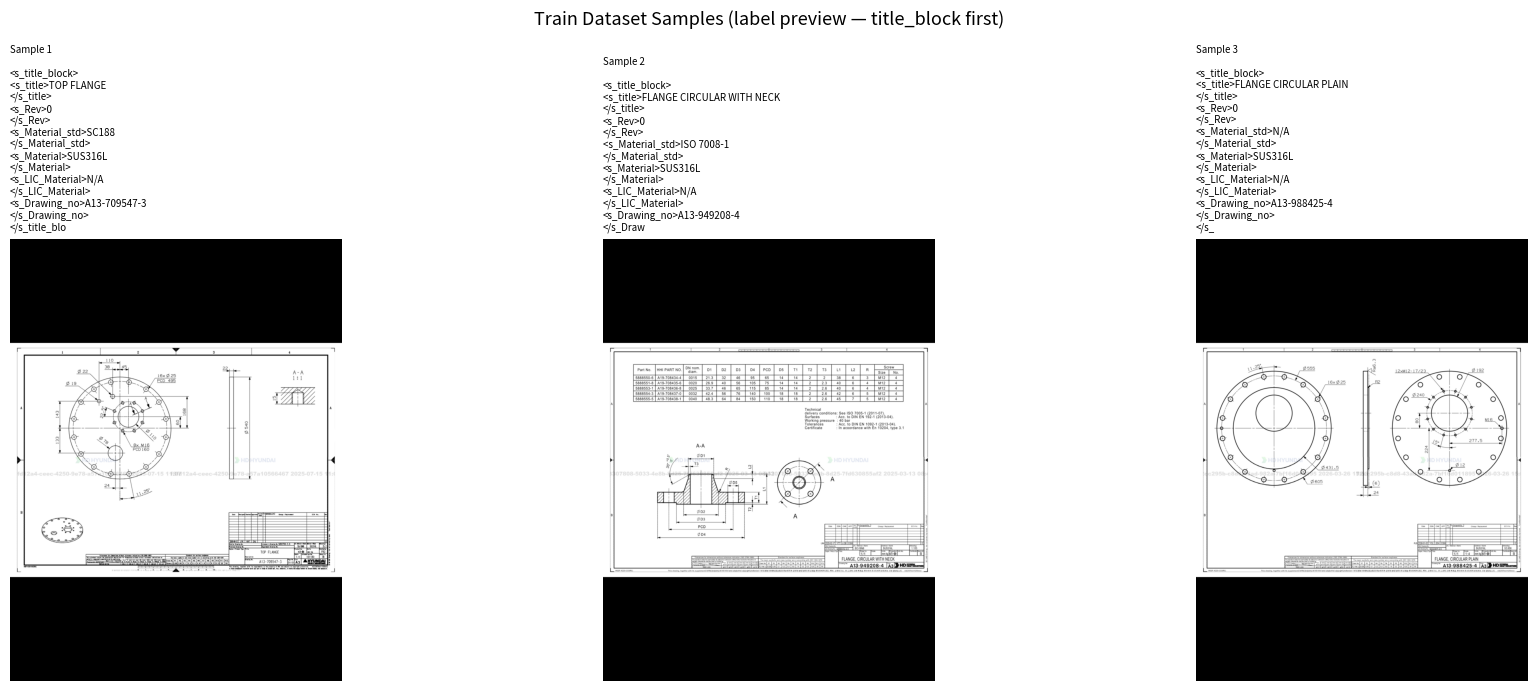


샘플 1 — 유효 토큰 수: 110 / 768
  (나머지 658개는 패딩 — loss 계산 제외)


In [12]:
# ── Step 3c: 샘플 시각화 ──────────────────────────────────────────
# 학습 데이터가 올바르게 로드됐는지 눈으로 확인합니다.
# 라벨(정답)을 핵심 필드(title_block) 우선 순서로, 더 길게 표시합니다.
# (target_sequence는 json2token이 키를 역순 정렬해 샘플마다 앞 필드가 달라지므로,
#  미리보기는 아래 PREVIEW_ORDER로 다시 정렬해 일관되게 보여줍니다.)
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

PREVIEW_ORDER = ["title_block", "dimensions", "bolt_holes",
                 "surface_finish", "gdt", "threads", "date"]
PREVIEW_CHARS = 220   # 표시할 토큰 문자 수 (이전 80 → 220)

def preview_seq(label: dict) -> str:
    # PREVIEW_ORDER에 있는 키를 먼저, 그 외 키는 뒤에 붙여 토큰화
    keys = [k for k in PREVIEW_ORDER if k in label] + \
           [k for k in label if k not in PREVIEW_ORDER]
    s = "".join(f"<s_{k}>" + json2token(label[k]) + f"</s_{k}>" for k in keys)
    return s[:PREVIEW_CHARS]

for idx, ax in enumerate(axes):
    i = idx + 1  # 1,2,3번째 샘플을 출력
    sample = train_ds[i]

    # pixel_values는 [-1, 1]로 정규화되어 있으므로 [0, 1]로 되돌려 표시
    img_tensor = sample["pixel_values"]
    img_np     = (img_tensor.permute(1, 2, 0).numpy() + 1) / 2  # [-1,1] → [0,1]
    img_np     = img_np.clip(0, 1)
    ax.imshow(img_np)
    ax.axis("off")

    # 로컬 모드: 라벨 dict를 파일에서 직접 읽어 핵심 필드 우선으로 미리보기 구성
    if getattr(train_ds, "mode", "local") == "local":
        label    = json.load(open(train_ds.samples[i][1], encoding="utf-8"))
        gt_short = preview_seq(label)
    else:
        gt_short = sample["target_sequence"][:PREVIEW_CHARS]
    # "<" 앞에 줄바꿈을 넣어 토큰 구조를 읽기 쉽게
    gt_short = gt_short.replace("<", "\n<")
    ax.set_title(f"Sample {i}\n{gt_short}", fontsize=7, loc="left")

plt.suptitle("Train Dataset Samples (label preview — title_block first)", fontsize=13)
plt.tight_layout()
plt.show()

# 유효 토큰 수 확인: -100이 아닌 위치 = 실제 정답 토큰 수
# max_length 중 실제 정보가 몇 토큰인지 파악할 수 있습니다
valid_tokens = (train_ds[1]["labels"] != -100).sum().item()
print(f"\n샘플 1 — 유효 토큰 수: {valid_tokens} / {CFG['model']['max_length']}")
print(f"  (나머지 {CFG['model']['max_length'] - valid_tokens}개는 패딩 — loss 계산 제외)")


## Step 4 – 학습 (Training)

`Seq2SeqTrainer`를 사용합니다.

| 주요 옵션 | 설명 |
|-----------|------|
| `predict_with_generate=True` | 평가 시 모델이 실제로 토큰을 생성하여 metric 계산 |
| `bf16=True` | Mixed Precision(bf16) — VRAM 절감, Donut에서 fp16보다 안정 |
| `gradient_accumulation_steps` | 실효 배치를 크게 유지하면서 VRAM 절감 |
| `load_best_model_at_end=True` | 학습 종료 후 val loss 최저 체크포인트를 자동 복원 |

In [13]:
# ── Step 4: 학습 실행 ─────────────────────────────────────────────
# Seq2SeqTrainer가 다음을 자동으로 처리합니다:
#   - 매 스텝: forward → loss 계산 → backward → 가중치 업데이트
#   - 매 eval_steps: 검증셋으로 eval_loss 측정
#   - 매 save_steps: 체크포인트 저장
#   - 학습 완료 후: eval_loss 최소 체크포인트 자동 복원
if CFG["wandb"]["enabled"]:
    import wandb
    wandb.init(
        project=CFG["wandb"]["project"],
        name=CFG["wandb"]["run_name"],
        config=CFG,
    )

tcfg = CFG["training"]

training_args = Seq2SeqTrainingArguments(
    output_dir                  = tcfg["output_dir"],
    num_train_epochs            = tcfg["num_epochs"],
    per_device_train_batch_size = tcfg["batch_size"],
    per_device_eval_batch_size  = tcfg["batch_size"],
    gradient_accumulation_steps = tcfg["gradient_accumulation_steps"],
    learning_rate               = tcfg["learning_rate"],
    warmup_steps                = tcfg["warmup_steps"],   # 초반 lr 웜업 구간
    weight_decay                = tcfg["weight_decay"],   # 과적합 방지 정규화
    bf16                        = tcfg.get("bf16", True),  # bf16 혼합정밀도 (Donut 안정적)
    fp16                        = tcfg.get("fp16", False),
    save_steps                  = tcfg["save_steps"],
    eval_steps                  = tcfg["eval_steps"],
    logging_steps               = tcfg["logging_steps"],
    save_total_limit            = 3,          # 가장 최신 체크포인트 3개만 보관
    eval_strategy               = "steps",    # transformers ≥4.45 변경된 파라미터명
    predict_with_generate       = True,       # 평가 시 실제로 토큰을 생성해서 비교
    dataloader_num_workers      = tcfg["dataloader_num_workers"],
    report_to                   = ["wandb"] if CFG["wandb"]["enabled"] else ["none"],
    load_best_model_at_end      = True,       # 학습 후 eval_loss 최저 모델 자동 복원
    metric_for_best_model       = "eval_loss",
    greater_is_better           = False,      # loss는 낮을수록 좋음
)

trainer = Seq2SeqTrainer(
    model         = model,
    args          = training_args,
    train_dataset = train_ds,
    eval_dataset  = val_ds,
)

# 실효 배치 크기 = batch_size × gradient_accumulation_steps
print(f"실효 배치 크기: {tcfg['batch_size']} × {tcfg['gradient_accumulation_steps']} = "
      f"{tcfg['batch_size'] * tcfg['gradient_accumulation_steps']}")
print(f"저장 경로    : {tcfg['output_dir']}")
print("\n학습 시작... (loss가 지속적으로 감소하는지 확인하세요)")
trainer.train()

# 최종 모델과 프로세서를 함께 저장합니다.
# 추론 시 같은 경로에서 둘 다 로드해야 합니다.
final_dir = os.path.join(tcfg["output_dir"], "final")
trainer.save_model(final_dir)
processor.save_pretrained(final_dir)
print(f"\n학습 완료! 모델 저장됨 → {final_dir}")


실효 배치 크기: 2 × 2 = 4
저장 경로    : checkpoints_drawings

학습 시작... (loss가 지속적으로 감소하는지 확인하세요)


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss,Validation Loss
50,8.234600,7.319967
100,5.468600,4.494204
150,2.877700,2.413508
200,2.074500,1.925713
250,1.479200,1.434821
300,1.103200,1.151836
350,0.810000,0.930702
400,0.596200,0.801186
450,0.460600,0.654183
500,0.357800,0.627491


There were missing keys in the checkpoint model loaded: ['decoder.lm_head.weight'].



학습 완료! 모델 저장됨 → checkpoints_drawings/final


## Step 5 – 평가 (Evaluation)

**Leaf-Match Score**: 예측 JSON과 정답 JSON의 모든 리프(leaf) 값을 비교하여 일치율을 계산합니다.  
(완전한 TED 구현을 원하면 `zss` 패키지를 사용하세요)

In [14]:
# ── Step 5a: 평가 유틸리티 ────────────────────────────────────────

def token2json(tokens: str) -> dict | str:
    '''모델이 생성한 토큰 시퀀스를 Python dict로 역변환.

    json2token()의 반대 과정입니다.
    예) "<s_total>12500</s_total>" → {"total": "12500"}

    정규표현식으로 <s_key>...</s_key> 패턴을 찾아 재귀적으로 파싱합니다.
    '''
    output = {}
    while tokens:
        # 여는 태그 <s_key> 탐색
        start = re.search(r"<s_(.+?)>", tokens)
        if not start:
            break
        key     = start.group(1)
        end_pat = f"</s_{key}>"
        end_pos = tokens.find(end_pat, start.end())
        if end_pos == -1:
            break
        value = tokens[start.end():end_pos]
        # 값 안에 중첩 태그가 있으면 재귀 호출로 파싱
        output[key] = token2json(value) if "<s_" in value else value.strip()
        tokens = tokens[end_pos + len(end_pat):]
    return output if output else tokens.strip()


def compute_leaf_match(pred: dict, gt: dict) -> float:
    '''예측 JSON과 정답 JSON의 최말단(leaf) 값 일치율을 계산합니다 (0~1).

    중첩 구조를 평탄화(flatten)한 뒤 경로별로 값을 비교합니다.
    예) {"menu": {"nm": "Burger"}} → {"/menu/nm": "Burger"}
    전체 정답 leaf 중 예측이 맞춘 비율을 반환합니다.
    '''
    def flatten(d, prefix=""):
        items = {}
        if isinstance(d, dict):
            for k, v in d.items():
                items.update(flatten(v, f"{prefix}/{k}"))
        elif isinstance(d, list):
            for i, v in enumerate(d):
                items.update(flatten(v, f"{prefix}[{i}]"))
        else:
            items[prefix] = str(d)
        return items

    pred_flat = flatten(pred)
    gt_flat   = flatten(gt)
    if not gt_flat:
        return 1.0 if not pred_flat else 0.0
    matches = sum(pred_flat.get(k) == v for k, v in gt_flat.items())
    return matches / len(gt_flat)  # 일치한 leaf 수 / 전체 정답 leaf 수

print("평가 유틸리티 정의 완료 ✓")


평가 유틸리티 정의 완료 ✓


In [15]:
# ── Step 5b: Validation set 전체 평가 ────────────────────────────
# ※ 학습이 완료된 뒤 실행하세요.
# 저장된 체크포인트를 로드하고 검증 데이터 전체에 추론 → Leaf-Match Score 계산.

CHECKPOINT     = os.path.join(CFG["training"]["output_dir"], "final")
MAX_NEW_TOKENS = CFG["model"]["max_length"]   # 학습 max_length(768)와 동일하게
EVAL_BATCH     = 1

# 저장된 체크포인트가 있으면 로드, 없으면 현재 메모리의 model 사용
if os.path.isdir(CHECKPOINT):
    eval_processor = DonutProcessor.from_pretrained(CHECKPOINT)
    eval_model     = VisionEncoderDecoderModel.from_pretrained(CHECKPOINT).to(device)
else:
    print(f"체크포인트 없음: {CHECKPOINT} — 현재 model 사용")
    eval_model, eval_processor = model, processor

eval_model.eval()

task_prompt = CFG["data"]["task_prompt"]
decoder_input_ids = eval_processor.tokenizer(
    task_prompt, add_special_tokens=False, return_tensors="pt"
).input_ids.to(device)

def _clean(seq: str) -> str:
    # 특수 토큰(BOS/EOS/PAD)과 task 토큰 제거 → token2json이 본문만 파싱하도록.
    # (task 토큰을 안 떼면 닫힘 태그 없는 키로 오인해 파싱 실패 → 점수가 0이 됨)
    for t in (eval_processor.tokenizer.eos_token, eval_processor.tokenizer.pad_token,
              eval_processor.tokenizer.bos_token, task_prompt):
        if t:
            seq = seq.replace(t, "")
    return seq.strip()

val_loader = DataLoader(val_ds, batch_size=EVAL_BATCH, shuffle=False, num_workers=2)

scores = []
with torch.inference_mode():
    for batch in tqdm(val_loader, desc="Evaluating"):
        pixel_values = batch["pixel_values"].to(device)
        outputs = eval_model.generate(
            pixel_values,
            decoder_input_ids = decoder_input_ids.expand(pixel_values.size(0), -1),
            max_new_tokens    = MAX_NEW_TOKENS,
            early_stopping    = True,
            pad_token_id      = eval_processor.tokenizer.pad_token_id,
            eos_token_id      = eval_processor.tokenizer.eos_token_id,
            use_cache         = True,
        )
        for i, seq in enumerate(outputs):
            pred_str = _clean(eval_processor.batch_decode([seq], skip_special_tokens=False)[0])
            gt_str   = _clean(batch["target_sequence"][i])
            pred_json, gt_json = token2json(pred_str), token2json(gt_str)
            if isinstance(pred_json, dict) and isinstance(gt_json, dict):
                scores.append(compute_leaf_match(pred_json, gt_json))
            else:
                scores.append(1.0 if pred_str == gt_str else 0.0)

mean_score = sum(scores) / len(scores) if scores else 0.0
print(f"\n평가 완료 — {len(scores)} 샘플")
print(f"Leaf-Match Score: {mean_score:.4f} ({mean_score*100:.2f}%)")
print("  (1.0 = 모든 필드 완벽 일치 / 0.0 = 전혀 불일치)")


Evaluating: 100%|██████████| 5/5 [00:10<00:00,  2.10s/it]


평가 완료 — 5 샘플
Leaf-Match Score: 0.0000 (0.00%)
  (1.0 = 모든 필드 완벽 일치 / 0.0 = 전혀 불일치)


## Step 6 – 추론 (Inference)

이미지 파일 한 장을 넣으면 JSON 결과를 반환합니다.

추론 모델 로드 완료 → checkpoints_drawings/final

입력: data/processed_drawings/val/images/A1459372702.png
추론 결과:
{
  "title_block": {
    "Rev": "",
    "Material": "SUS16"
  },
  "machined": "/"
}


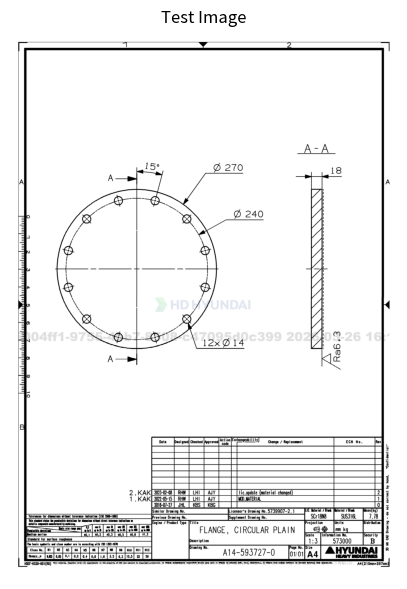

In [16]:
# ── Step 6: 단일 이미지 추론 ──────────────────────────────────────
# 학습된 모델을 체크포인트(checkpoints_drawings/final)에서 "직접 로드"해 추론합니다.
# → Step 5b 평가를 건너뛰어도 이 셀만으로 동작합니다.
import os, glob, tempfile, re

device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_DIR = os.path.join(CFG["training"]["output_dir"], "final")   # = checkpoints_drawings/final
assert os.path.isdir(CKPT_DIR), f"체크포인트 없음: {CKPT_DIR} — 먼저 Step 4 학습을 실행하세요."

# 학습 결과(모델 + 프로세서)를 로드
eval_processor = DonutProcessor.from_pretrained(CKPT_DIR)
eval_model     = VisionEncoderDecoderModel.from_pretrained(CKPT_DIR).to(device).eval()
print(f"추론 모델 로드 완료 → {CKPT_DIR}")

# token2json(Step 5a)이 없을 때를 대비한 폴백 정의 (Step 5a를 안 돌렸어도 동작)
if "token2json" not in globals():
    def token2json(tokens):
        output = {}
        while tokens:
            start = re.search(r"<s_(.+?)>", tokens)
            if not start:
                break
            key = start.group(1); end_pat = f"</s_{key}>"
            end_pos = tokens.find(end_pat, start.end())
            if end_pos == -1:
                break
            value = tokens[start.end():end_pos]
            output[key] = token2json(value) if "<s_" in value else value.strip()
            tokens = tokens[end_pos + len(end_pat):]
        return output if output else tokens.strip()


@torch.inference_mode()
def predict(image_path: str, task: str | None = None) -> dict:
    """이미지 경로 → 추출 정보(dict). task가 None이면 CFG의 task_prompt 사용."""
    task = task or CFG["data"]["task_prompt"]
    image        = Image.open(image_path).convert("RGB")
    pixel_values = eval_processor(image, return_tensors="pt").pixel_values.to(device)
    decoder_ids  = eval_processor.tokenizer(
        task, add_special_tokens=False, return_tensors="pt"
    ).input_ids.to(device)

    outputs = eval_model.generate(
        pixel_values,
        decoder_input_ids = decoder_ids,
        max_new_tokens    = CFG["model"]["max_length"],
        early_stopping    = True,
        pad_token_id      = eval_processor.tokenizer.pad_token_id,
        eos_token_id      = eval_processor.tokenizer.eos_token_id,
        use_cache         = True,
    )

    # 토큰 ID → 문자열 → (BOS/EOS/PAD/task 토큰 제거) → dict
    sequence = eval_processor.batch_decode(outputs, skip_special_tokens=False)[0]
    for t in (eval_processor.tokenizer.eos_token, eval_processor.tokenizer.pad_token,
              eval_processor.tokenizer.bos_token, task):
        if t:
            sequence = sequence.replace(t, "")
    return token2json(sequence.strip())


# ── 데모: 검증셋 첫 이미지로 추론 ────────────────────────────────
val_dir = os.path.join(CFG["data"]["local_val_dir"], "images")
cands   = sorted(glob.glob(os.path.join(val_dir, "*")))
if not cands:                       # 폴백: 원본 도면 폴더
    cands = sorted(glob.glob("data/drawings/images/*"))
test_image_path = cands[0]

result = predict(test_image_path)
print(f"\n입력: {test_image_path}")
print("추론 결과:")
print(json.dumps(result, indent=2, ensure_ascii=False))

# 이미지 시각화
fig, ax = plt.subplots(figsize=(5, 8))
ax.imshow(Image.open(test_image_path).convert("RGB"))
ax.axis("off"); ax.set_title("Test Image")
plt.show()


## 추론 결과를 JSON 형식으로 출력

모델이 생성한 **원시 토큰 문자열**(raw output)을 정리 → dict → 보기 좋은 JSON 문자열로 변환합니다.

> ⚠️ **학습이 부족하면** 토큰 구조가 깨져(예: `<___read>`, `<s/_read>`) 정상 JSON이 나오지 않습니다.
> 이 경우 아래 함수는 파싱 가능한 부분만 JSON으로 만들고, 실패하면 `_raw`에 원문을 담아 안전하게 보여줍니다.
> **깨진 출력 자체를 고치려면 파서가 아니라 추가 학습이 필요합니다.**


In [17]:
# ── 추론 결과 → JSON 변환/출력 ──────────────
# 모델 원시 출력 문자열을 받아 JSON 문자열로 변환합니다.
# token2json(Step 5a) · eval_processor(Step 5b/6)가 먼저 정의돼 있어야 합니다.
import json, re

def output_to_json(raw: str, task_prompt: str = None, indent: int = 2) -> str:
    """모델 원시 출력 문자열 → JSON 문자열.

    1) 특수 토큰(BOS/EOS/PAD)과 task 토큰 제거
    2) token2json으로 <s_key>...</s_key> 구조를 dict로 파싱
    3) 파싱 실패(구조 손상) 시 {"_raw": ...}로 원문을 감싸 반환
    """
    task_prompt = task_prompt or CFG["data"]["task_prompt"]
    s = raw
    try:
        for t in (eval_processor.tokenizer.eos_token, eval_processor.tokenizer.pad_token,
                  eval_processor.tokenizer.bos_token):
            if t:
                s = s.replace(t, "")
    except Exception:
        pass
    s = s.replace(task_prompt, "").strip()

    parsed = token2json(s)
    if not isinstance(parsed, dict) or not parsed:
        parsed = {"_raw": raw.strip(),
                  "_note": "토큰 구조가 불완전합니다 — 학습 부족일 수 있습니다."}
    return json.dumps(parsed, indent=indent, ensure_ascii=False)


# ── 사용법 A) 모델 원시 출력 문자열을 직접 변환 ──────────────
# generate() 직후 batch_decode로 얻은 문자열을 그대로 넣으세요.
raw_output = "<s_drawing><s_title_block><s_title> FLANGE</s_title> ...붙여넣기... </s_title_block>"
print(output_to_json(raw_output))

# ── 사용법 B) 이미지로 추론한 결과를 JSON으로 출력 ──────────────
# predict()는 이미 dict를 반환하므로 그대로 json.dumps 하면 됩니다.
result = predict("data/drawings/images/A1463607470.png")
print(json.dumps(result, indent=2, ensure_ascii=False))


{
  "title_block": {
    "title": "FLANGE"
  }
}
"<s_title_block><s_title>.. FGE<s_Rev></s_Rev> SC86<s_Material>SUS16</s_Material> NA<s_Drawing_no>14</s_Material> NA<s_Drawing_no>1414<s_Drawing_no>16</s_Material> NA<s_Drawing_no>14<s_Drawing_no>14<s_Drawing_no>14<s_surface_finish> NA<s_Drawing_no>5</s_surface_finish><s_perpendicularity>/</s_perpendicularity> NA<s_Drawing_no>5</s_surface_finish><s_perpendicularity>/</s_perpendicularity> NA<s_concentricity>/</s_flatness> NA</s_gdt><s_thickness></s_thickness> 14<s_outer_diameter></s_outer_diameter> 120<s_bore_diameter>5<s_bore_diameter>5<s_bore_diameter></s_bore_diameter><s_date>/</s_date><s_outer> 95<s_diameter></s_diameter> 15<s_count></s_count><s_inner> NA<s_pcd>/</s_size> NA<s_count>/</s_count></s_bolt_holes></s_bolt_holes>/</s_count></s_bolt_holes>/</s_count></s_bolt_holes>/</s_count></s_bolt_holes>/</s_count></s_bolt_holes>/</s_count></s_bolt_holes>/</s_count></s_bolt_holes>/</s_count></s_bolt_holes>/</s_count></s_bolt_holes>/</s_co

### (선택) 태그 없이 깔끔하게 출력

파싱 결과(dict)의 값에 `</s_...>`·`<sep/>` 같은 **잔여 태그**가 섞여 있으면 제거하고 보여줍니다.
(학습이 잘 되면 보통 깨끗하지만, 불완전 출력일 때 유용)


In [18]:
# ── 태그 제거 후 출력 ──────────────
import re, json
from pprint import pprint

def strip_tags(o):
    """dict/list/str 안의 <...> 태그(<s_..>, </s_..>, <sep/>)를 모두 제거"""
    if isinstance(o, dict):
        return {k: strip_tags(v) for k, v in o.items()}
    if isinstance(o, list):
        return [strip_tags(v) for v in o]
    if isinstance(o, str):
        return re.sub(r"<[^>]*>", "", o).strip()
    return o

clean = strip_tags(result)   # result = Step 6 / 위 셀의 predict() 결과
print(json.dumps(clean, indent=2, ensure_ascii=False))   # 한글 유지 — JSON 권장
# pprint(clean, indent=2, width=80, compact=False)        # pprint를 원하면 이 줄 사용

# <sep/>를 구분 기호로 살리고 싶으면 strip_tags의 re.sub를 아래로 교체:
#   return re.sub(r"<(?!sep/>)[^>]*>", "", o).replace("<sep/>", ", ").strip()


".. FGE SC86SUS16 NA14 NA141416 NA141414 NA5/ NA5/ NA/ NA 14 12055/ 95 15 NA/ NA////////////////////////////////////////////////////////////////"


---
## 도면 파인튜닝 체크리스트 & 트러블슈팅

### 실행 순서 요약
1. **Step 0 ~ 공통 import** 실행
2. **Step 1 (CFG)** — 그대로 실행 (도면용으로 이미 설정됨)
3. **라벨 점검** — 빈 값 비율 확인, 가능한 한 라벨을 채운다
4. **데이터 분리** — `data/processed_drawings/{train,val}` 생성
5. **Step 2 ~ 3** — 모델/데이터셋 로드 (`<s_drawing>` 토큰 자동 추가 확인)
6. **Step 4** — 학습 (`checkpoints_drawings/`에 저장)
7. **Step 5 ~ 6** — 평가 및 추론

### 자주 겪는 문제
| 증상 | 원인 | 해결 |
|------|------|------|
| 출력이 빈 값/엉뚱한 값 | 라벨에 빈 값이 많음, 데이터 부족 | 라벨 채우기, 데이터 추가, 에폭↑ |
| `eval_loss`가 다시 증가 | 과적합 (데이터 적을 때 흔함) | `load_best_model_at_end`가 최적 모델 복원 / 에폭↓ / 데이터↑ |
| 작은 글자 인식 실패 | 입력 해상도 부족 | `image_size`를 키움 (VRAM↑) |
| CUDA out of memory | 배치/해상도 과다 | `batch_size=1`, `gradient_accumulation_steps`↑ |
| 생성이 중간에 잘림 | `max_length` 부족 | `max_length`↑ (최대 768) |

### 데이터 양에 따른 권장 설정
- ~50장: `num_epochs 100`, 과적합 주의, 결과는 PoC 수준
- 수백 장: `num_epochs 50~80`
- 수천 장: `num_epochs 10~30`

> 핵심은 **라벨 품질과 스키마 일관성**입니다. 모든 라벨 JSON의 키 구조를 동일하게 유지하세요.
